In [3]:
import json
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import(classification_report, confusion_matrix, roc_auc_score, roc_curve)
tf.random.set_seed(42)
np.random.seed(42)


In [4]:
#Train, validate and test the data loaded
train_df = pd.read_csv('heart_disease_train.csv')
test_df = pd.read_csv('heart_disease_test.csv')
val_df = pd.read_csv('heart_disease_val.csv')



X_train = train_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_train = train_df["Heart_Disease"].values.astype(np.float32)

X_val = val_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_val = val_df['Heart_Disease'].values.astype(np.float32)

X_test = test_df.drop(columns=['Heart_Disease']).values.astype(np.float32)
y_test = test_df['Heart_Disease'].values.astype(np.float32)

print(f'Train: {X_train.shape}')
print(f'Val: {X_val.shape}')
print(f'Test: {X_test.shape}')
print(f'Number of features: {X_train.shape[1]}')

Train: (18627, 16)
Val: (5285, 16)
Test: (5979, 16)
Number of features: 16


In [5]:
with open('heart_disease_metadata.json') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
scaler_mean = np.array(metadata['scaler_mean'], dtype=np.float32)
scaler_scale = np.array(metadata['scaler_scale'], dtype=np.float32)

print(f'Loaded metadata for{len(feature_cols)} features')
scaler_scale

Loaded metadata for16 features


array([14.490715  ,  0.49998444,  6.3466773 ,  0.7975433 ,  0.74745375,
        0.8748711 ,  0.8941631 ,  0.45809102,  0.4003057 ,  0.43613592,
        0.4909653 ,  0.2991607 , 23.09571   , 17.249577  , 31.678753  ,
       43.04224   ], dtype=float32)

In [6]:
def build_ann(n_features):
   inputs = keras.Input(shape=(n_features,), name='features')


   x = keras.layers.Dense(128,kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
   x = keras.layers.BatchNormalization()(x)
   x = keras.layers.Activation('relu')(x)
   x = keras.layers.Dropout(0.3)(x)

   x = keras.layers.Dense(64,kernel_regularizer=keras.regularizers.l2(1e-4))(x)

   x = keras.layers.BatchNormalization()(x)
   x = keras.layers.Activation('relu')(x)
   x = keras.layers.Dropout(0.3)(x)

   x = keras.layers.Dense(64)(x)
   x = keras.layers.Activation('relu')(x)
   x = keras.layers.Dropout(0.2)(x)

   outputs = keras.layers.Dense(1,activation='sigmoid',name='prob')(x)

   return keras.Model(inputs,outputs,name='heart_diseaseANN')


In [7]:
model = build_ann(X_train.shape[1])
model.summary()

Model: "heart_diseaseANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ features (InputLayer)                │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ prob (Dense)                         │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,425 (60.25 KB)

 Trainable params: 15,041 (58.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss = 'binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
    ]
)

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',patience=25,

        restore_best_weights=True, mode='max', verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_heart_disease_model.keras', monitor='val_loss',
        save_best_only = True, mode='max', verbose=0
    ),
]

In [10]:
history = model.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print(f"\nEpochs run: {len(history.history['loss'])}")

print(f"Best val loss: {max(history.history['val_loss']):.4f}")

Epoch 1/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.8344 - auc: 0.9222 - loss: 0.3609 - precision: 0.8303 - recall: 0.8082 - val_accuracy: 0.9289 - val_auc: 0.9836 - val_loss: 0.1827 - val_precision: 0.9172 - val_recall: 0.9307
Epoch 2/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8978 - auc: 0.9656 - loss: 0.2478 - precision: 0.8886 - recall: 0.8914 - val_accuracy: 0.9307 - val_auc: 0.9856 - val_loss: 0.1724 - val_precision: 0.9110 - val_recall: 0.9429
Epoch 3/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9071 - auc: 0.9710 - loss: 0.2284 - precision: 0.8971 - recall: 0.9034 - val_accuracy: 0.9315 - val_auc: 0.9871 - val_loss: 0.1646 - val_precision: 0.9108 - val_recall: 0.9449
Epoch 4/300
583/583 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9127 - auc: 0.9746 - loss: 0.2143 - precision: 0.9035 - recall: 0.9089 - val_accuracy: 0.9383 - val_auc: 0.9886 - val_loss: 0.1564 - val_precision: 0.9228 - val_recall: 0.9462
Epoch 5/300
583/583 ━━━━━━

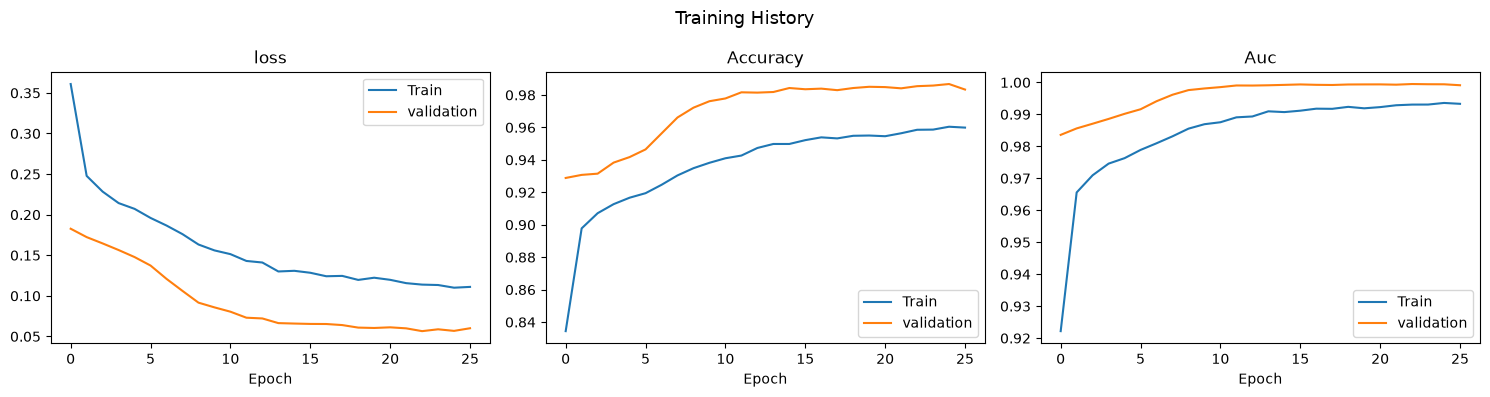

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='validation')
axes[0].set_title('loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train')
axes[2].plot(history.history['val_auc'], label='validation')
axes[2].set_title('Auc')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.savefig('heart_disease.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
model.load_weights('best_heart_disease_model.keras')

test_results = model.evaluate(X_test, y_test,verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f'{name:<12}: {value:.4f}')

loss        : 0.1933
compile_metrics: 0.9207


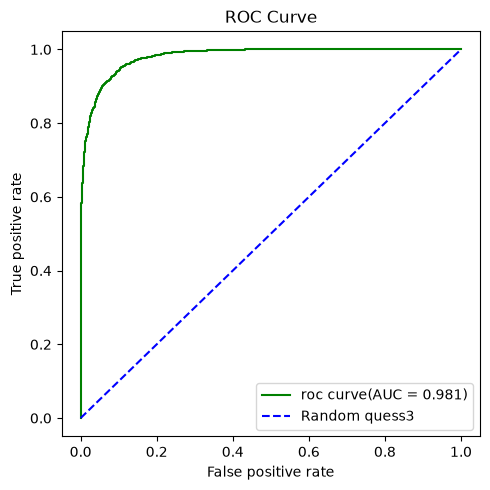

ROC-AUC: 0.9809


In [13]:
from sklearn.metrics import(classification_report, confusion_matrix, roc_auc_score, roc_curve)
y_prob = model.predict(X_test, verbose = 0).flatten()
auc_score = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize = (5, 5))
plt.plot(fpr, tpr, color='green', label=f'roc curve(AUC = {auc_score:.3f})')
plt.plot([0,1],[0,1], color='blue', linestyle='--', label='Random quess3')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve_png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ROC-AUC: {auc_score:.4f}')

                  precision    recall  f1-score   support

No Heart Disease       0.93      0.92      0.93      3205
   Heart Disease       0.91      0.92      0.92      2774

        accuracy                           0.92      5979
       macro avg       0.92      0.92      0.92      5979
    weighted avg       0.92      0.92      0.92      5979



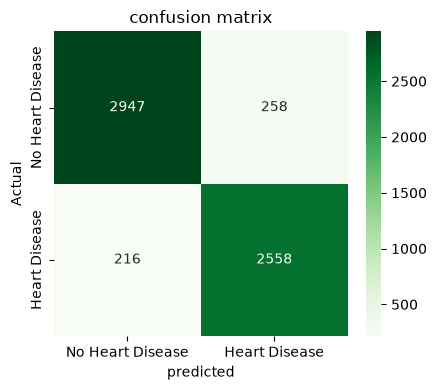

In [14]:
y_pred = (y_prob >= 0.5).astype(int)
from sklearn.preprocessing import StandardScaler
import seaborn as sns

print(classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease']))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.ylabel("Actual")
plt.xlabel("predicted")
plt.title('confusion matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_formalaria.png', dpi=150, bbox_inches = 'tight')
plt.show()